In [2]:
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

/home/lolero/IdeaProjects/MyProjects/js-modules/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [3]:
import numpy as np


def calculate_l2(v1, v2):
  return np.linalg.norm(v1 - v2) ** 2

In [4]:
import textwrap

import matplotlib.pyplot as plt


def wrap_labels(labels, width):
  return ["\n".join(textwrap.wrap(label, width)) for label in labels]


def plot(data, words):
  fig, ax = plt.subplots()
  ax.imshow(data, cmap="Blues")

  labels = wrap_labels(words, 30)
  ax.set_xticks(np.arange(len(words)), labels=labels)
  ax.set_yticks(np.arange(len(words)), labels=labels)

  ax.xaxis.tick_top()
  ax.xaxis.set_label_position("top")

  plt.setp(ax.get_xticklabels(), rotation=45, ha="left", rotation_mode="anchor")

  # for i in range(len(words)):
  #     for j in range(len(words)):
  #         text = ax.text(j, i, round(data[i, j], 2),
  #                     ha="center", va="center")

  fig.tight_layout()
  plt.show()

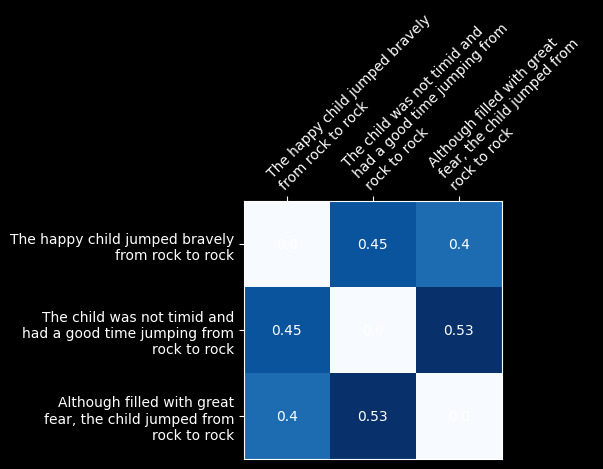

In [5]:
words = [
  "The happy child jumped bravely from rock to rock",
  "The child was not timid and had a good time jumping from rock to rock",
  "Although filled with great fear, the child jumped from rock to rock",
]

embs = [np.array(embeddings.embed_query(word)) for word in words]

data = np.array([[calculate_l2(e1, e2) for e1 in embs] for e2 in embs])

plot(data, words)